In [1]:
#import cupy as cp
import numpy as np
import scipy.signal as signal
from scipy.fft import fft, fftfreq, fftshift
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, wiener

### Introdução a filtros adaptativos
---
Um filtro adaptativo é um filtro digital que tem caracteristicas de autoajuste. Esses filtros desempenham um papel importante nos produtos modernos de processamento de sinal digital (DSP) em áreas como cancelamento de eco telefônico, cancelamento de ruído, equalização de canais de comunicação, entre outros. Os filtros adaptativos funcionam geralmente para a adaptação e sobreposição, pois em casos que o ruído de interferência é forte, usar um filtro tradicional não preservará o espctro de sinal desejado.

Para entender melhor o conceito de filtros adaptativos, podemos analisar um cancelador de ruídos simples. Conforme mostrado na figura abaixo, o sistema *DSP* consiste em dois canais de conversão **ADC**. O primeiro microfone captura a fala desejada. No entanto, devido ao ambiente ruidoso, o sinal é contaminado com o ruído. Um segundo microfone é usado para capturar o ruído, alimentando assim o fitro adaptativo.

<center><img src="https://github.com/Medupl/CoppeliaSim/blob/main/images/Optic/Cancelador-de-ruido.png?raw=true"/></center>
$$\text{Fonte: Livro: Digital Signal Processing: Fundamentals and Applications}$$

Neste exemplo podemos assumir que o sinal com ruído é uma versão linear da fonte do ruído, então podemos estimar o ruído no sinal desejado usando um filtro adaptativo, que possui um algoritmo de *Minimos Quadrados Médios* (**LMS**), que ajusta os coeficientes e quando temos $y(n) ≈ n(n)$, podemos usar a expressão de erro e então o ruído é cancelado. O filtro usado no exemplo acima é definido como *Filtro de resposta ao impulso* (**FIR**), o coeficiente $w(n)$ é ajustado pelo algoritmo **LMS**. Onde temos as seguintes expressões:
$$\begin{equation}
y(n) = w(n).x(n) \\
d(n) = s(n) + n(n) \\
e(n) = d(n) - y(n) \\
w(n + 1) = w(n) + 0.01.e(n).x(n)
\end{equation}$$

__Por que os filtros adaptativos são a melhor escolha?__

Filtros adaptativos são a melhor escolha em sistemas onde as características do ambiente ou do sinal variam ao longo do tempo e não podem ser modeladas de forma estática. Eles ajustam seus coeficientes automaticamente para minimizar erros ou alcançar objetivos específicos, como cancelamento de ruído, predição de sinais ou equalização de canais.

### Teoria básica do filtro Wiener
---
Muitos algoritmos adaptativos podem ser vistos como aproximações do filtro Wiener discreto, onde a saída $y(n)$ é uma soma ponderada, dada por:
$$y(n) = w_0x(n) + w_1x(n - 1) + ⋯ + w_{N - 1}x(n - N + 1)$$

O fitro Wiener ajusta sua saída para ser o mais próximo do ruído $n(n)$, assim, na saída o ruído é cancelado. Considere um caso de peso único de $y(n) = wx(n)$ e fazendo algumas manipulações temos:
$$e(n) = d(n) - wx(n) ⟹ e^2(n) = (d(n) - wx(n))^2 = d^2(n) - 2d(n)wx(n) + w^2x^2(n)$$

Usando a expectativa estatistica, temos:
$$E(e^2(n)) = E(d^2(n)) - 2wE(d(n)x(n)) + w^2E(x^2(n))$$
onde:
> $J = E(e^2(n)) =$ erro quadratico médio. \\
  $σ^2 = E(d^2(n)) =$ potência do sinal corrompido. \\
  $P = E(d(n)x(n)) =$ correlação cruzada de d(n) e x(n). \\
  $R = E(x^2(n)) = $ autocorrelação.

Substituindo na equação temos:
$$J = σ^2 - 2w.P + w^2.R$$

A melhor solução para o peso $w$ ocorre quando o $J_{min}$ é alcançado, assim quando fazemos a derivada igual a zero, temos:
$$\frac{dJ}{dw} = -2P + 2wR = 0 \\
w = P.R^{-1}$$

Em geral, o filtro Wiener tem N coeficientes e pode ser escrito em forma de matriz como:
$$\begin{equation}
y(n) = \sum_{k = 0}^{N - 1} w_k x(n - k) = W^T X(n)
\end{equation}$$

Fazendo essa alteração na função **MSE**, temos:
$$J = E(e^2(n)) = E(d(n) - W^TX(n))^2 \\ \begin{equation}
J = σ^2 - 2W^T.P + W^T.R.W
\end{equation}$$

Fazendo a derivada para zero, temos:
$$\frac{dJ}{dW} = -2.P + W.R = 0 \\
W = P. R^{-1}$$

__Qual a função do filtro de Wiener?__

O filtro de Wiener é um filtro projetado para minimizar o erro médio quadrático (MSE) entre o sinal desejado e o sinal estimado. Ele é usado em situações onde o sistema é estacionário e conhecido. Esse filtro ajuda a estimar valores futuros de um sinal baseado no histórico.

>**Prós:** \\
> + Fornece a solução ótima para sinais estacionários.
> + Minimiza o erro médio quadrático (MSE).

> __Contras:__ \\
+ Requer conhecimento prévio da estatística do sinal, o que não é viável em sistemas dinâmicos.
+ Mais complexo computacionalmente em comparação ao LMS.

### Exemplo 1:
---
Queremos usar o filtro de Wiener para ajustar os sinais com ruído e aproximá-los do sinal original. O filtro de Wiener é eficiente em situações onde queremos minimizar o erro quadrático médio entre o sinal filtrado e o sinal original.

+ Sinal desejado $s(n)=sin(w_0 n+ϕ)$, onde $w_0 =0.1π$.
+ Dois sinais de ruído $v_1(n) \ e \ v_2(n)$, gerados pelo modelo AR(1):
  - $v_1(n)=0.8v_1(n - 1) + g(n)$
  - $v_2(n)=0.6v_2(n - 1) + g(n)$
  -Onde
𝑔
(
𝑛
)
g(n) é um ruído branco.

In [ ]:
# Parâmetros
np.random.seed(42)  # Fixar a seed para reprodutibilidade
N = 200
w0 = 0.1 * np.pi
phi = 1

# Sinal desejado s(n)
n = np.arange(N)
s = np.sin(w0 * n + phi)

# Ruído branco g(n) e sinal ruidoso d(n)
g = np.random.randn(N)
dn = s + g

# Gerar v1(n) com modelo AR(1)
v1 = np.zeros(N)
for i in range(1, N):
    v1[i] = 0.8 * v1[i - 1] + g[i]

# Gerar v2(n) com modelo AR(1)
v2 = np.zeros(N)
for i in range(1, N):
    v2[i] = 0.6 * v2[i - 1] + g[i]

# Combinar os sinais s(n) com ruído v1(n) e v2(n)
s_v1 = s + v1
s_v2 = s + v2

# Função para estimar a potência do ruído para ajustar o filtro.
def estimate_noise_power(signal, noise_window=25):
    return np.var(signal[:noise_window])

# Estimar a potência do ruído para os sinais v1 e v2
noise_power_v1 = estimate_noise_power(s_v1)
noise_power_v2 = estimate_noise_power(s_v2)

# Aplicar o filtro de Wiener com parâmetros ajustados
s_v1_filtered = wiener(s_v1, mysize=10, noise=noise_power_v1)
s_v2_filtered = wiener(s_v2, mysize=10, noise=noise_power_v2)

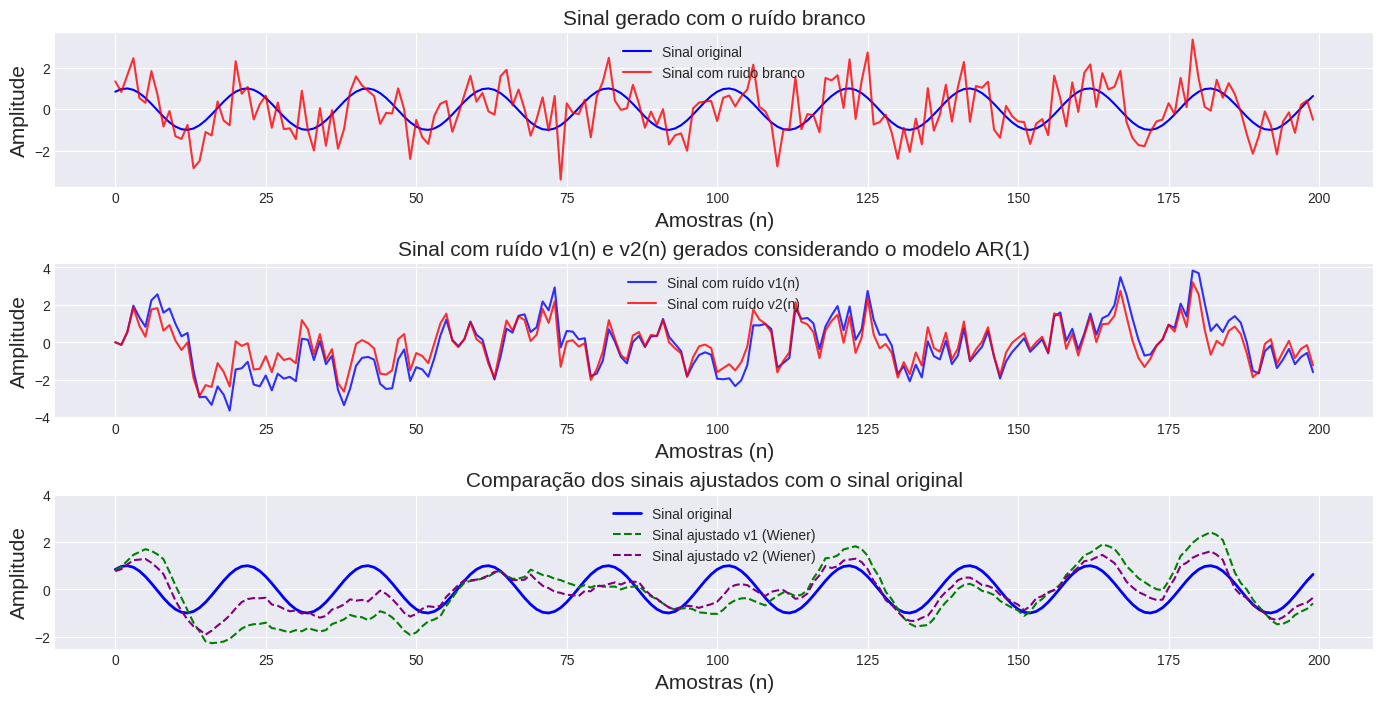

In [ ]:
# Plotar os resultados
plt.style.use("seaborn-v0_8-darkgrid")
fig, axis = plt.subplots(3, 1, figsize=(17, 8))
fig.subplots_adjust(hspace=0.5)

# Plot 1: Sinal com ruído gerado para o teste
axis[0].plot(n, s, label="Sinal original", color="blue")
axis[0].plot(n, dn, label="Sinal com ruido branco", color="r", alpha=0.8)
axis[0].set_title("Sinal gerado com o ruído branco", fontsize=15)
axis[0].set_xlabel("Amostras (n)", fontsize=15)
axis[0].set_ylabel("Amplitude", fontsize=15)
axis[0].legend(loc="best")

# Plot 2: Sinal com ruído v1(n) e v2(n) gerados considerando o modelo AR(1)
axis[1].plot(n, v1, label="Sinal com ruído v1(n)", color="b", alpha=0.8)
axis[1].plot(n, v2, label="Sinal com ruído v2(n)", color="r", alpha=0.8)
axis[1].set_title("Sinal com ruído v1(n) e v2(n) gerados considerando o modelo AR(1)", fontsize=15)
axis[1].set_xlabel("Amostras (n)", fontsize=15)
axis[1].set_ylabel("Amplitude", fontsize=15)
axis[1].legend()

# Plot 3: Comparação final entre os sinais filtrados e o sinal original
axis[2].plot(n, s, label="Sinal original", color="blue", linewidth=2)
axis[2].plot(n, s_v1_filtered, label="Sinal ajustado v1 (Wiener)", color="green", linestyle="--")
axis[2].plot(n, s_v2_filtered, label="Sinal ajustado v2 (Wiener)", color="purple", linestyle="--")
axis[2].set_ylim(-2.5, 4)
axis[2].set_title("Comparação dos sinais ajustados com o sinal original", fontsize=15)
axis[2].set_xlabel("Amostras (n)", fontsize=15)
axis[2].set_ylabel("Amplitude", fontsize=15)
axis[2].legend()

plt.show()

### Previsão Linear Direta
---

A previsão linear lida com a probabilidade de prever um valor futuro a partir de valores passados observados. Considerando um ponto $x(n)$, usando valores de $x(n - 1) ⋯ x(n - P)$. A previsão pode ser obtida por:
$$\begin{equation}
  x´(n) = \sum_{k = 1}^{P} a_k x(n - k)
\end{equation}$$

A diferença entre $x(n) \ e \ x´(n)$ é dada pelo erro de previsão:
$$e_f(n) = x(n) - x´(n)$$

### Algoritmo de descida mais íngrime
---

Como vimos, resolver a solução de *Wiener* requer muitos cálculos, para isso usamos um algoritmo **LMS** que usa o algoritmo de descida mais íngrime para minimizar o **MSE**.
$$\begin{equation}
w(n + 1) = w(n) - μ\frac{dJ}{dw(n)}
\end{equation}$$

onde μ é a constante que controla a velocidade de convergência.

Para caso geral, temos: $y(n) = W(n)^T.X(n)$ \
Em forma vetorial: $w(n + 1) = W(n) - μΔJ_{W(n)}$

### Algoritmo de mínimos quadrados médios (**LMS**)
---

A aplicação do algoritmo de descida mais íngrime ainda inclui cálculos estatísticos de um bloco de dados. Para solucionar usamos um algortimo baseado em amostra **LMS**, onde:
$$J = e^2(n) = (d(n) - w(n)x(n))^2 \\
\frac{dJ}{dw(n)} = -2e(n)x(n)$$

Substituindo na expressão do filtro de descida, encontramos o *LMS* para atualizar um caso de peso único.
$$\begin{equation}
w(n + 1) = W(n) +2μ e(n)x(n)
\end{equation}$$
onde $ 0 < μ < \frac{1}{λ_{max}}, λ_{max}$ é o autovalor da matriz $R = E(X^T(n)X(n))$

Para caso geral, temos:
$$y(n) = w_0x(n) + w_1x(n - 1) + ⋯ + w_{N - 1}x(n - N + 1)$$
$$w_k(n + 1) = W_k(n) +2μ e(n)x(n - k)$$

Em forma vetorial: $W(n + 1) = W(n) +2μ e(n)X(n)$

### Algoritmo de mínimos quadrados recursivos
---

Os algoritmos *RLS* visam minimizar a soma dos quadrados da diferença entre o sinal desejado e o sinal de saída do filtro. Eles calculam os coeficientes do filtro de forma recursiva, são mais rápidos e possuem excelente desempenho em relação ao *LMS*.

Dado um filtro adaptivo linear $y(n) = W^T(n) X(n)$, onde:

$$W(n) = [w_0(n) w_1(n) ⋯ w_{N - 1}(n)]^T$$
$$X(i) = [x(i) x(i - 1) ⋯ x(i - N + 1)]^T$$

Incluindo a função de erro ponderado exponencial com um fator de esquecimento λ.
$$\begin{equation}
𝜻(n) = \sum_{i = 1}^{n} λ^{n - i} e^2(n)
\end{equation}$$
com $0 < λ < 1 \ e \ e(i) = d(i) - W^T(n)X(i)$

Derivando a função $𝜻(n)$ por W(n) encontramos:
$$\sum_{i = 1}^{n} λ^{n - i} X^T(i)W(n) = \sum_{i = 1}^{n} λ^{n - i} X(i)d(i) $$

Do lado esquerdo temos a matriz de correlação $R$ e do lado direito temos o vetor de correlação cruzada $P$ e assim temos:
$$\begin{equation}
R(n) = \sum_{i = 1}^{n} λ^{n - i} X^T(i)W(n) = λ.R(n - 1) + X(n)X^T(n)
\end{equation}$$
$$\begin{equation}
P(n) = \sum_{i = 1}^{n} λ^{n - i} X(i)d(i) = λ.P(n - 1) + d(n)X(n)
\end{equation}$$

Realizando várias manipulações encontramos todos os parametros para o filtro RLS. Semelhante ao LMS, ao omitir o índice de tempo para $w_k(n)$, ou seja, $w_k = w_r(n)$, podemos concluir o algoritmo *RLS* com as seguintes etapas:

> 1. Iniciar $W = [w_0(n) w_1(n) ⋯ w_{N - 1}(n)]^T$ para valores arbitrários. \\
  Iniciar Q = δ.I, onde I é a matriz identidade e δ é o inverso da potência do sinal de entrada.
> 2. Calcule o vetor de inovação e ganho.
  $$α = d(n) - X^T(n)W$$
  $$K = \frac{Q.X(n)}{λ + X^T(n).Q.X(n)}$$
> 3. Atualize os coeficientes do filtro.
  $$ W = W + k.α$$
> 4. Atualize a matriz Q, produza a saída do filtro e medir o erro.
  $$Q = [Q - kX^T(n).Q]/λ$$
  $$y(n) = W^TX(n)$$
  $$e(n) = d(n) - y(n)$$

### Exemplo 1
---
Neste exemplo, o algoritmo LMS é utilizado para cancelar ruídos adaptativamente, onde o sinal de entrada é contaminado por ruído e o filtro LMS ajusta-se para minimizar o erro entre o sinal desejado e o sinal de saída.

In [ ]:
# Parâmetros do sinal
fs = 8000
N = 500
mu = 0.01
t = np.arange(N) / fs

# Sinal e ruído
wen = np.sin(2 * np.pi * 1000 * t)
x = np.random.randn(N)
n = np.convolve(x, np.array([0, 0, 0, 0, 0.5]), mode='same')
d = wen + n

# Filtro LMS
tam = 21
w = np.zeros(tam)
y = np.zeros(len(t))
e = np.zeros(len(t))
for m in range(tam, N):
    y[m] = np.sum(w * x[m-tam:m][::-1])
    e[m] = d[m] - y[m]
    w += 2 * mu * e[m] * x[m-tam:m][::-1]

# Análise Espectral.
WEN = 2 * np.abs(fft(wen)) / len(wen)
WEN[0] = WEN[0] / 2
# Cálculo do espectro de amplitude unilateral do sinal corrompido.
D = 2 * np.abs(fft(d)) / len(d)
D[0] = D[0] / 2
# Cálculo do espectro de amplitude unilateral do sinal cancelado do ruido.
E = 2 * np.abs(fft(e)) / len(e)
E[0] = E[0] / 2

# Vetor de frequências.
f = np.arange(0, len(wen) / 2 + 1) * fs / len(wen)

# Conversão para NumPy para visualização
"""
t = np.asnumpy(t)
d = np.asnumpy(d)
y = np.asnumpy(y)
e = np.asnumpy(e)"""

'\nt = np.asnumpy(t)\nd = np.asnumpy(d)\ny = np.asnumpy(y)\ne = np.asnumpy(e)'

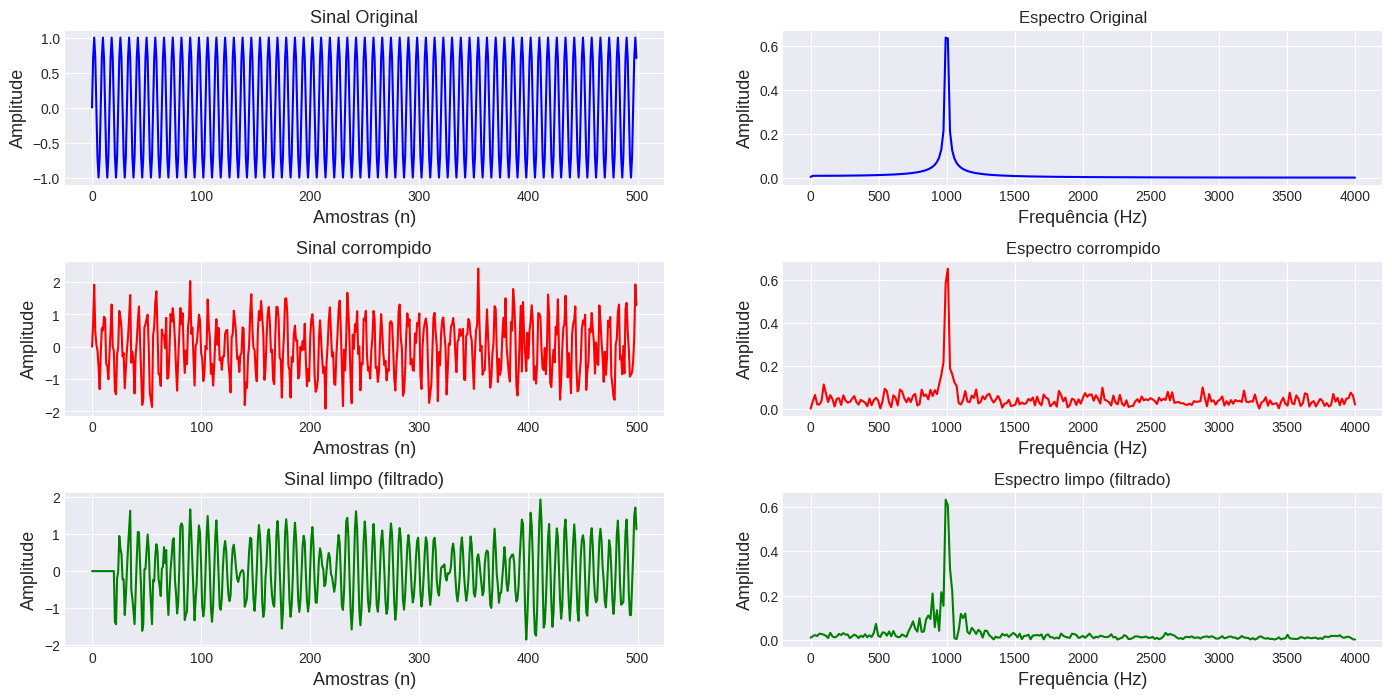

In [ ]:
# Configurando os gráficos.
plt.style.use("seaborn-v0_8-darkgrid")
fig, axis = plt.subplots(3, 2, figsize=(17, 8))
fig.subplots_adjust(hspace=0.5)

# Configurando uma caracteristica geral.
for ax in axis.flatten():
    ax.set_xlabel('Amostras (n)', fontsize = 13)
    ax.set_ylabel('Amplitude', fontsize = 13)

# Plotando o gráfico do Sinal original.
axis[0, 0].plot(wen, color='blue')
axis[0, 0].set_title('Sinal Original', fontsize = 13)

# Plotando o gráfico do Espectro do sinal original.
axis[0, 1].plot(f, WEN[:len(f)], color='blue')
axis[0, 1].set_title('Espectro Original')
axis[0, 1].set_xlabel('Frequência (Hz)', fontsize = 13)

# Plotando o gráfico do Sinal corrompido.
axis[1, 0].plot(d, color='red')
axis[1, 0].set_title('Sinal corrompido', fontsize = 13)

# Plotando o gráfico do Espectro do sinal corrompido.
axis[1, 1].plot(f, D[:len(f)], color='red')
axis[1, 1].set_title('Espectro corrompido')
axis[1, 1].set_xlabel('Frequência (Hz)', fontsize = 13)

# Plotando o gráfico do Sinal limpo (filtrado).
axis[2, 0].plot(e, color='green')
axis[2, 0].set_title('Sinal limpo (filtrado)', fontsize = 13)

# Plotando o gráfico do Espectro do sinal limpo (filtrado).
axis[2, 1].plot(f, E[:len(f)], color='green')
axis[2, 1].set_title('Espectro limpo (filtrado)')
axis[2, 1].set_xlabel('Frequência (Hz)', fontsize = 13)

plt.show()

### Identificação de Sistema Adaptativa com Algoritmo LMS
---
No processo de identificação de sistema adaptativa, o objetivo é modelar ou aproximar um sistema desconhecido usando um filtro adaptativo, geralmente um filtro FIR (Finite Impulse Response) ajustado com o algoritmo LMS (Least Mean Squares). Essa técnica é amplamente utilizada em cenários onde o comportamento de um sistema não é totalmente conhecido, mas um conjunto de entradas e saídas do sistema está disponível para análise.

Como Funciona o Algoritmo LMS na Identificação de Sistemas

+ Sinal de Entrada ($x[n]$): Um sinal conhecido, como um sinal senoidal ou ruído branco, é aplicado tanto ao sistema desconhecido quanto ao filtro adaptativo. Esse sinal funciona como uma entrada de teste para caracterizar o sistema.

+ Sistema Desconhecido: Esse sistema possui uma resposta ao impulso que queremos identificar. Quando o sinal de entrada passa pelo sistema desconhecido, ele gera uma saída desejada $d[n]$, que representa a resposta verdadeira do sistema.

+ Filtro Adaptativo: O filtro adaptativo tenta "aprender" a resposta ao impulso do sistema desconhecido. Inicialmente, o filtro começa com coeficientes arbitrários (geralmente zeros) e ajusta esses coeficientes a cada iteração para reduzir o erro.

+ Erro ($e[n]$): O erro é a diferença entre a saída do filtro adaptativo $(y[n])$ e a saída desejada $(d[n])$. Esse erro indica quão próximo o filtro está de imitar o sistema desconhecido.

+ Ajuste dos Coeficientes: Com base no erro, o algoritmo LMS ajusta os coeficientes do filtro adaptativo. Esse ajuste é feito para minimizar o erro médio quadrático *(Mean Squared Error - MSE)* entre a saída do filtro e a saída desejada, movendo os coeficientes na direção que reduz o erro.

### Aplicações: Cancelamento de ruído, Modelagem de sistema e Aprimoramento de linha.

### __Cancelamento de Ruído (Noise Cancellation)__:

Como vimos anteriormente, o sistema *DSP* consiste em dois canais *ADC*. O primeiro captura o sinal original $s(n)$ e o sinal com ruído $n(n)$devido ao ambiente ruidoso. O segundo captura somente o ruído que irá alimentar o filtro adaptivo que usará um algoritmo adaptivo para ajustar os coeficientes e ter na saída uma estimativa do sinal limpo, anulando o ruído do ambiente.

O cancelamento de ruído é uma técnica fundamental em processamento digital de sinais, usada para reduzir ou eliminar ruídos indesejados de sinais de interesse. O objetivo é melhorar a qualidade do sinal principal, isolando-o de interferências sonoras. A técnica mais comum para cancelamento de ruído é o uso de filtros adaptativos, especialmente o filtro LMS (Least Mean Square). Esse filtro aprende em tempo real a característica do ruído e o subtrai do sinal original. Um exemplo típico de aplicação é o cancelamento de ruído em comunicações telefônicas, onde interferências externas ou ruídos de fundo podem ser removidos sem comprometer a clareza do sinal de voz.

+ Principais Benefícios:
  - Melhoria da inteligibilidade do sinal.
  - Redução de interferências que podem comprometer a comunicação.
  - Aplicação em fones de ouvido com cancelamento de ruído ativo, onde o dispositivo é capaz de isolar sons indesejados para uma experiência auditiva mais limpa.

In [15]:
# Parâmetros do sinal
fs = 8000
N = 500
mu = 0.01
t = np.arange(N) / fs

# Sinal e ruído
wen = np.sin(2 * np.pi * 1000 * t)
x = np.random.randn(N)
n = np.convolve(x, np.array([0, 0, 0, 0, 0.5]), mode='same')
d = wen + n

# Inicialização do filtro adaptativo RLS
tam = 21
w = np.zeros(tam)
Q = np.eye(tam) * np.mean(np.sum(x * x))
lamda = 0.96  # Fator de esquecimento
y = np.zeros(N)
e = np.zeros(N)

# Filtragem adaptativa usando o algoritmo RLS
for n in range(tam, N):
    xx = x[n:n-tam:-1]
    alpha = d[n] - np.dot(w, xx)
    k = np.dot(Q, xx) / (lamda + np.dot(xx.T, np.dot(Q, xx)))
    w = w + k.T * alpha
    Q = (Q - np.outer(k, np.dot(xx.T, Q))) / lamda
    y[n] = np.dot(w, xx)
    e[n] = d[n] - y[n]


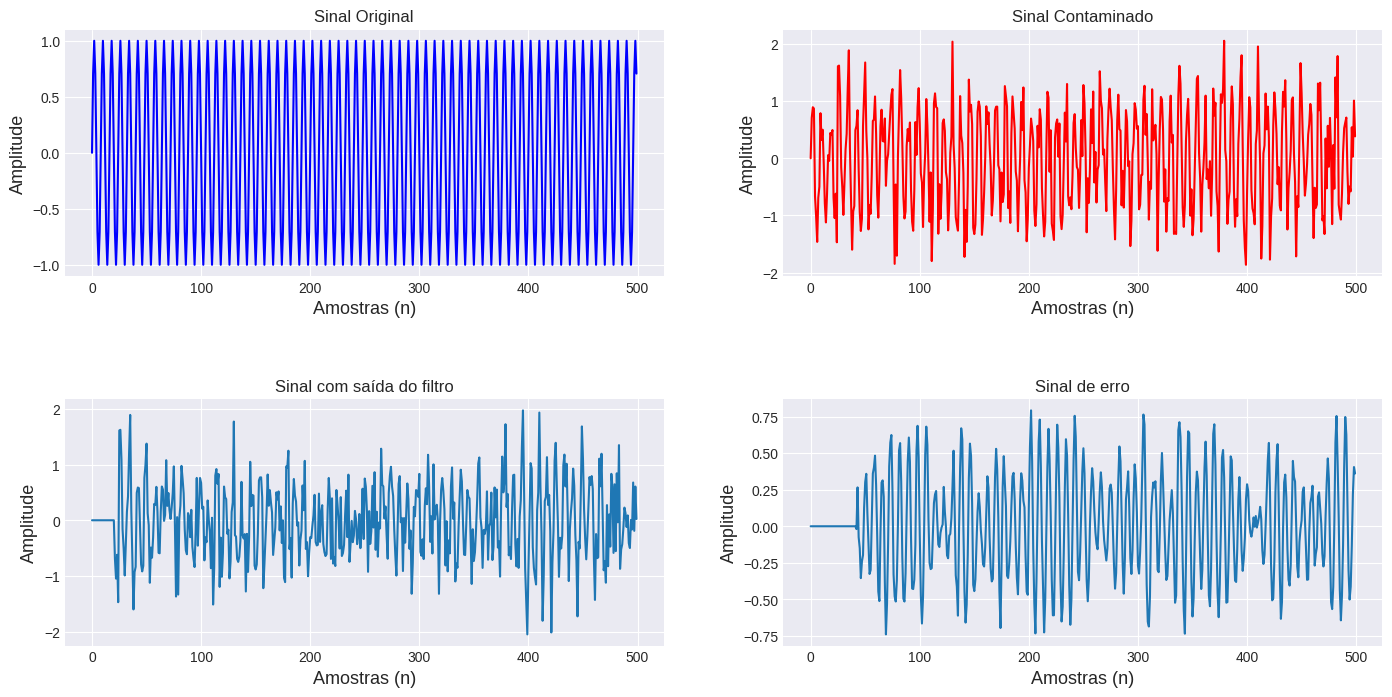

In [18]:
# Configurando os gráficos.
plt.style.use("seaborn-v0_8-darkgrid")
fig, axis = plt.subplots(2, 2, figsize=(17, 8))
fig.subplots_adjust(hspace=0.5)

for ax in axis.flatten():
    ax.set_xlabel('Amostras (n)', fontsize = 13)
    ax.set_ylabel('Amplitude', fontsize = 13)

# Plotando gráfico do Sinal Original.
axis[0, 0].plot(wen, color = "b", label="Sinal original (wen)")
axis[0, 0].set_title("Sinal Original")

# Plotando gráfico do Sinal Contaminado.
axis[0, 1].plot(d, color = "r", label="Sinal Contaminado (d)")
axis[0, 1].set_title("Sinal Contaminado")

# Plotando gráfico do Sinal de saída.
axis[1, 0].plot(y, label="Saída do filtro (y)")
axis[1, 0].set_title("Sinal com saída do filtro")

# Plotando gráfico do Sinal de erro.
axis[1, 1].plot(e, label="Erro (e)")
axis[1, 1].set_title("Sinal de erro")

plt.show()


### __Modelagem de Sistema (System Modeling):__

Outra aplicação do filtro adaptativo é a modelagem de sistema. O filtro adaptativo pode continuar rastreando o comportamento de um sistema desconhecido usando a entrada e a saída do sistema desconhecido após a convergência do filtro adaptativo, a saída do filtro adaptativo $y(n)$ será o mais próximo possível da saída do sistema desconhecido. Como tanto o sistema desconhecido quanto o filtro adaptativo respondem à mesma entrada, a função de transferência do filtro adaptativo se aproximará daquela do sistema desconhecido.

A modelagem de sistema refere-se à criação de um modelo matemático que representa as características de um sistema físico. Em processamento de sinais, a modelagem de sistemas é essencial para simular e prever o comportamento de sistemas complexos, como filtros ou canais de comunicação. A modelagem pode ser feita usando técnicas adaptativas, que permitem que o modelo ajuste automaticamente seus parâmetros com base nas condições de entrada. Esse processo é útil em sistemas onde as características variam ao longo do tempo e é necessário um acompanhamento dinâmico das mudanças.

+ Principais Benefícios:
  - Previsão e controle do comportamento de sistemas físicos complexos.
  - Otimização de desempenho em sistemas de comunicação, ao se adaptar a diferentes condições do canal.
  - Aplicação em engenharia para o desenvolvimento de sistemas robustos e eficientes.

  No exemplo abaixo, usamos uma entrada que consiste em tons de 500, 1500 e 2500 Hz. Podemos prever que a saída do sistema desconhecido conterá apenas um tom de 1500 Hz, já que os outros dois tons são rejeitados pelo sistema desconhecido. No domínio do tempo, as formas de onda de saída do sistema desconhecido d(n) e a saída do filtro adaptativo y(n) são quase idênticas
após 70 amostras quando o algoritmo LMS converge.

<ipython-input-22-6d6d088c2432>:23: RuntimeWarning: divide by zero encountered in log10
  plt.plot(w, 20 * np.log10(abs(h)))


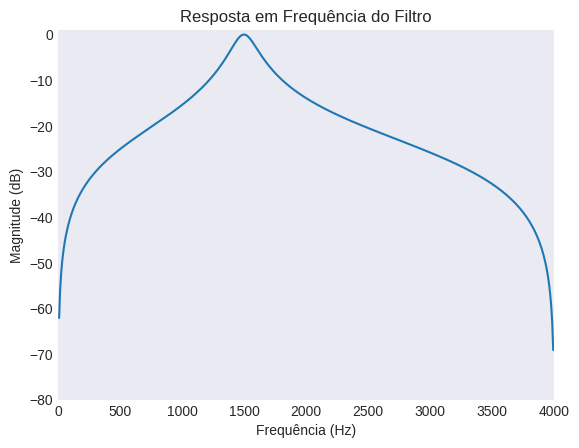

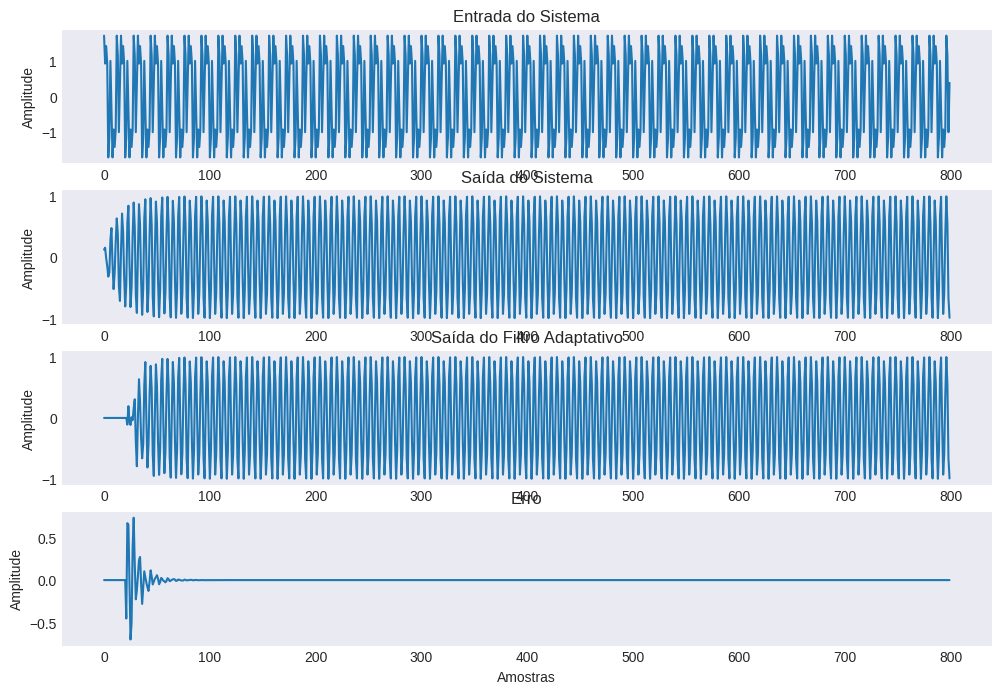

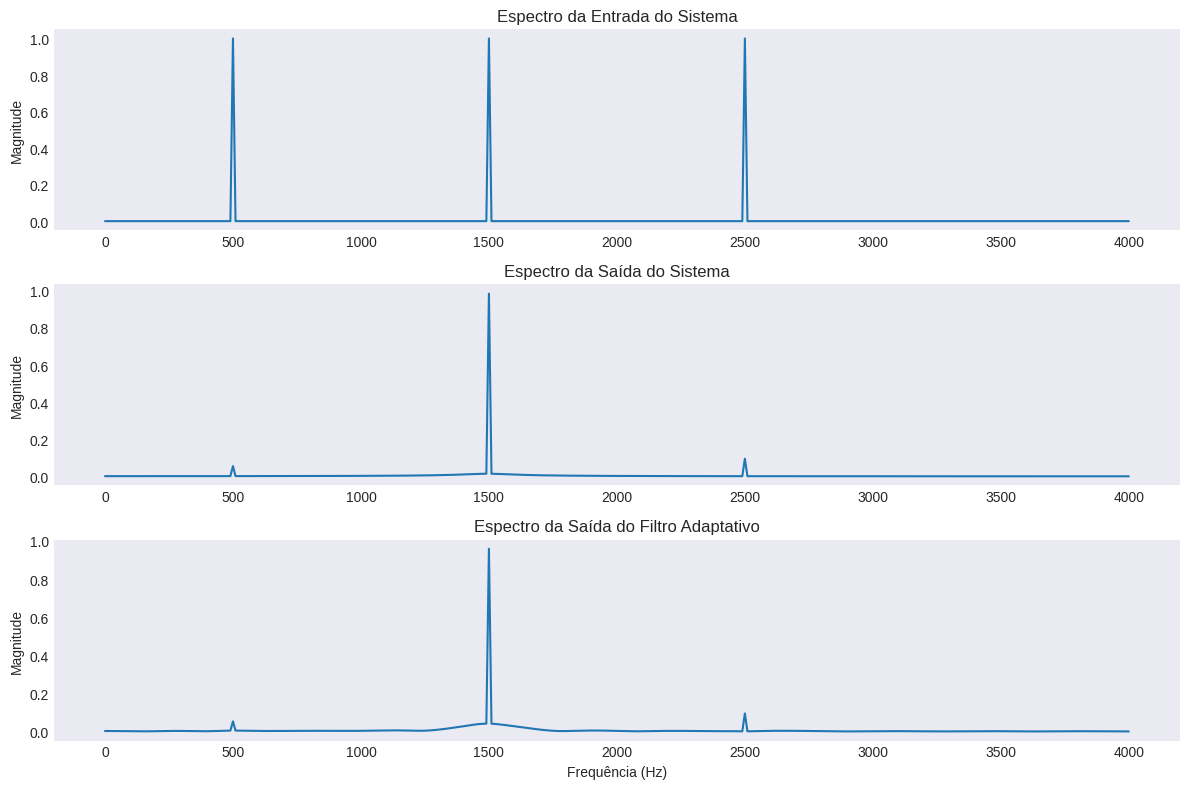

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, freqz

# Parâmetros do sistema
fs = 8000  # Taxa de amostragem
T = 1 / fs  # Período de amostragem

# Frequências de corte no domínio digital
f1 = 1400  # Frequência inferior (Hz)
f2 = 1600  # Frequência superior (Hz)

# Normalização das frequências para o método butter
f1_norm = f1 / (fs / 2)  # Normaliza pela frequência de Nyquist
f2_norm = f2 / (fs / 2)  # Normaliza pela frequência de Nyquist

# Projeto do filtro passa-banda
b, a = butter(1, [f1_norm, f2_norm], btype='band')

# Resposta em frequência do filtro
w, h = freqz(b, a, worN=512, fs=fs)
plt.figure()
plt.plot(w, 20 * np.log10(abs(h)))
plt.title("Resposta em Frequência do Filtro")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.axis([0, fs / 2, -80, 1])

# Sinais de entrada e saída do sistema
t = np.arange(0, 0.1, T)  # Vetor de tempo
x = np.cos(2 * np.pi * 500 * t) + np.sin(2 * np.pi * 1500 * t) + np.cos(2 * np.pi * 2500 * t + np.pi / 4)  # Entrada
d = lfilter(b, a, x)  # Saída do sistema desconhecido

# Parâmetros do algoritmo LMS
mu = 0.01  # Fator de convergência
w = np.zeros(21)  # Inicialização dos coeficientes do filtro
y = np.zeros(len(t))  # Inicialização da saída do filtro adaptativo
e = np.zeros(len(t))  # Inicialização do erro

# Algoritmo LMS
for m in range(21, len(t)):
    xx = x[m-21:m][::-1]  # Vetor de entrada reverso
    y[m] = np.dot(w, xx)  # Saída do filtro adaptativo
    e[m] = d[m] - y[m]  # Erro instantâneo
    w += 2 * mu * e[m] * xx  # Atualização dos coeficientes

# Espectro de amplitude
X = 2 * np.abs(np.fft.fft(x)) / len(x)
D = 2 * np.abs(np.fft.fft(d)) / len(d)
Y = 2 * np.abs(np.fft.fft(y)) / len(y)
f = np.arange(0, len(x)//2 + 1) * fs / len(x)

# Gráficos de sinais e espectros
plt.figure(figsize=(12, 8))

# Sinais no tempo
plt.subplot(4, 1, 1)
plt.plot(x)
plt.grid()
plt.title("Entrada do Sistema")
plt.ylabel("Amplitude")

plt.subplot(4, 1, 2)
plt.plot(d)
plt.grid()
plt.title("Saída do Sistema")
plt.ylabel("Amplitude")

plt.subplot(4, 1, 3)
plt.plot(y)
plt.grid()
plt.title("Saída do Filtro Adaptativo")
plt.ylabel("Amplitude")

plt.subplot(4, 1, 4)
plt.plot(e)
plt.grid()
plt.title("Erro")
plt.xlabel("Amostras")
plt.ylabel("Amplitude")

# Espectros
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(f, X[:len(f)])
plt.grid()
plt.title("Espectro da Entrada do Sistema")
plt.ylabel("Magnitude")

plt.subplot(3, 1, 2)
plt.plot(f, D[:len(f)])
plt.grid()
plt.title("Espectro da Saída do Sistema")
plt.ylabel("Magnitude")

plt.subplot(3, 1, 3)
plt.plot(f, Y[:len(f)])
plt.grid()
plt.title("Espectro da Saída do Filtro Adaptativo")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude")

plt.tight_layout()
plt.show()


####  __Aprimoramento de linha.__

Estudamos a filtragem adaptativa por meio de outro exemplo de aplicação: aprimoramento de linha. Se um conteúdo de frequência de sinal
é muito estreito em comparação com a largura de banda e muda com o tempo, então o sinal pode ser aprimorado eficientemente pelo filtro adaptativo, que é o aprimoramento de linha.

A linha aprimorada consiste em um elemento de atraso para atrasar o sinal corrompido por amostras $Δ$ para produzir uma entrada para o filtro adaptativo.
O filtro adaptativo é, na verdade, um preditor linear do sinal de banda estreita desejado. Um *filtro adaptativo FIR* de dois toques pode prever uma sinusoide. O valor de Δ é geralmente determinado por experimentos ou experiência
na prática para atingir o melhor sinal aprimorado.


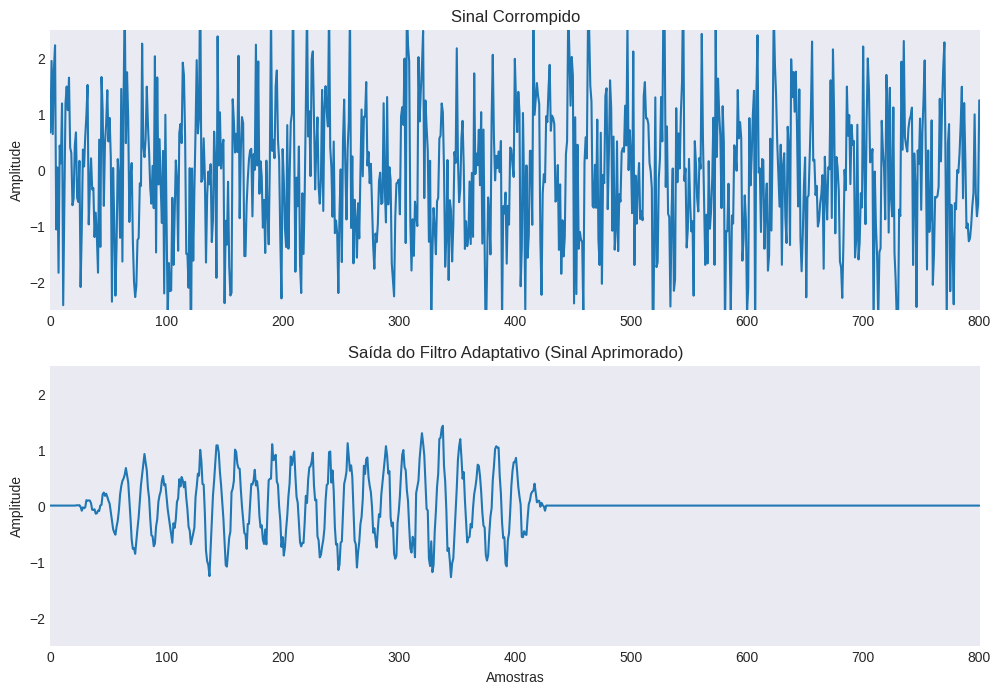

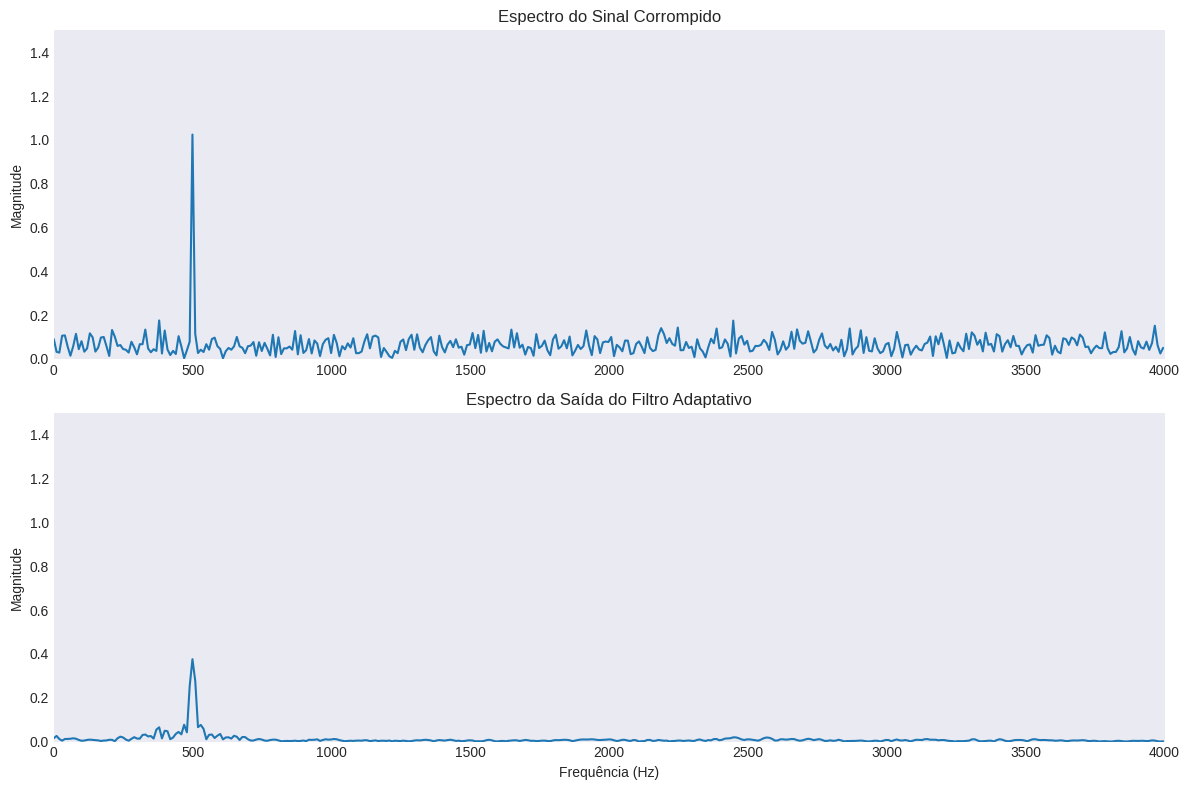

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros do sistema
fs = 8000  # Taxa de amostragem
T = 1 / fs  # Período de amostragem
t = np.arange(0, 0.1 + T, T)  # Vetor de tempo (1 segundo de duração)

# Geração do sinal
n = np.random.randn(len(t))  # Ruído branco gaussiano
d = np.cos(2 * np.pi * 500 * t) + n  # Tom de 500 Hz com ruído

# Filtro de atraso
x = np.concatenate(([0, 0, 0, 0, 0, 1], np.zeros(len(d) - 6)))  # Filtro de atraso manual
x = np.convolve(d, x, mode="same")  # Aplica o filtro de atraso ao sinal

# Algoritmo LMS
mu = 0.001  # Taxa de aprendizado
w = np.zeros(21)  # Inicialização dos coeficientes do filtro adaptativo
y = np.zeros(len(t))  # Inicialização da saída do filtro adaptativo
e = np.zeros(len(t))  # Inicialização do vetor de erro

# Filtragem adaptativa usando o algoritmo LMS
for m in range(21, len(t)):
    xx = x[m-21:m][::-1]  # Vetor de entrada reverso
    y[m] = np.dot(w, xx)  # Saída do filtro adaptativo
    e[m] = d[m] - y[m]  # Erro instantâneo
    w += 2 * mu * e[m] * xx  # Atualização dos coeficientes

# Espectros de amplitude
D = 2 * np.abs(np.fft.fft(d)) / len(d)
D[0] = D[0] / 2
Y = 2 * np.abs(np.fft.fft(y)) / len(y)
Y[0] = Y[0] / 2
f = np.arange(0, len(x)//2 + 1) * fs / len(x)

# Plotagem dos sinais e espectros
plt.figure(figsize=(12, 8))

# Sinais no tempo
plt.subplot(2, 1, 1)
plt.plot(d)
plt.grid()
plt.axis([0, len(x), -2.5, 2.5])
plt.title("Sinal Corrompido")
plt.ylabel("Amplitude")

plt.subplot(2, 1, 2)
plt.plot(y)
plt.grid()
plt.axis([0, len(y), -2.5, 2.5])
plt.title("Saída do Filtro Adaptativo (Sinal Aprimorado)")
plt.ylabel("Amplitude")
plt.xlabel("Amostras")

# Espectros
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(f, D[:len(f)])
plt.grid()
plt.axis([0, fs / 2, 0, 1.5])
plt.title("Espectro do Sinal Corrompido")
plt.ylabel("Magnitude")

plt.subplot(2, 1, 2)
plt.plot(f, Y[:len(f)])
plt.grid()
plt.axis([0, fs / 2, 0, 1.5])
plt.title("Espectro da Saída do Filtro Adaptativo")
plt.ylabel("Magnitude")
plt.xlabel("Frequência (Hz)")

plt.tight_layout()
plt.show()


### __Cancelamento periódico de interferência__

Um sinal de áudio pode ser corrompido por interferência periódica e nenhuma referência de ruído disponível. Tais exemplos incluem a reprodução de fala ou música com a interferência de zumbido de fita, ou ruído sintonizável, ou
motor de veículo, ou interferência de linha de energia. O filtro adaptativo usa a versão atrasada do sinal corrompido x(n) para prever a interferência periódica. O número de amostras atrasadas é selecionado por meio de experimentos que determinam o desempenho do filtro adaptativo. Após a convergência, o filtro adaptativo preverá a interferência como:
$$\begin{equation}
y(n) = \sum_{k = 0}^{N - 1} w_k(n) x(n - k) ≈ Acos(2\pi fn/fs)
\end{equation}$$

Portanto, o sinal de erro contém apenas o sinal de áudio desejado:
$$e(n) ≈ s(n)$$

### __Cancelamento de interferência de eletrocardiograma.__

Na gravação de eletrocardiogramas **(ECG)**, frequentemente existe
interferência indesejada de 60 Hz, juntamente com seus harmônicos, nos dados registrados. Essa interferência vem da linha de energia, incluindo efeitos de indução magnética, correntes de deslocamento em condutores ou no corpo do paciente e interconexões e imperfeições do equipamento.

A entrada primária é retirada do pré-amplificador de ECG, enquanto uma entrada de referência de 60 Hz é retirada de uma tomada de parede com atenuação adequada. Após o condicionamento adequado do sinal, a interferência digital $x(n)$ é adquirida pelo processador de sinal digital $(DS)$. Um filtro FIR adaptativo com N taps e o algoritmo *LMS* podem ser usados para esta aplicação:
$$y(n) = w_0x(n) + w_1x(n - 1) + ⋯ + w_{N - 1}x(n - N + 1)$$

Então, após a convergência do filtro adaptativo, a interferência estimada é subtraída do sinal primário do pré-amplificador de ECG para produzir o sinal de saída e(n), no qual a interferência de 60 Hz é cancelada:

$$e(n) = d(n) - y(n) = s(n) + n(n) - x (n) ≈ s(n)$$

No monitoramento fetal, é importante cancelar o ECG da mãe, pois o ECG fetal ajuda a monitorar a condição do bebê antes e durante o parto. No entanto, o sinal captado do abdômen da mãe é frequentemente contaminado por ruídos, como atividade muscular, movimento fetal e o próprio ECG materno. Para reduzir essa interferência, são usadas quatro ou mais derivações torácicas como referência. Um eletrodo no abdômen captura o sinal fetal $d(n)$, que pode estar misturado com o ECG da mãe. Um filtro adaptativo é então aplicado para prever e subtrair o ECG materno, isolando o sinal do bebê.

### __Cancelamento de Eco em Circuitos Telefônicos de Longa Distância.__

Nas transmissões telefônicas de longa distância, problemas de incompatibilidade de impedância podem causar vazamentos de sinal, conhecidos como eco. Isso acontece porque o balanceamento das redes no híbrido nunca é perfeito devido a fatores como variações de temperatura e degradação das linhas.

Por exemplo, quando o falante B fala, seu sinal $x_B(n)$ chega ao falante A, mas parte dele vaza e retorna para B, fazendo com que ele ouça sua própria voz como eco. O mesmo pode acontecer no caminho inverso, com o falante A.

Para resolver esse problema, usa-se um *filtro adaptativo* em cada extremidade do sistema. No lado do falante A, o filtro usa o sinal de entrada de B como referência e ajusta seus coeficientes para aproximar sua saída ao sinal vazado, cancelando o eco. Esse processo melhora a qualidade das chamadas e reduz desconfortos durante a comunicação.

$$y_A(n) = \sum_{k = 0}^{N - 1} w_k(n)x_B(n - k) ≈ x'_B (n)$$

### Referências
---
1. **Tan, L., & Jiang, J.**. *Digital Signal Processing: Fundamentals and Applications*. 3ª Edição. AP, 2019
2. **Moodle USP**. *Filtros de Wiener*. Disponível em: [https://edisciplinas.usp.br/.../aula5.pdf](https://edisciplinas.usp.br/pluginfile.php/5814216/mod_resource/content/1/APDS-Quarentena-aula5.pdf). Acessado em: 23 de novembro de 2024.
3. **Aprenda Fácil**. *O que é: Filtro de Wiener - Entenda sua Aplicação*. Disponível em: [https://estatisticafacil.org/glossario/o-que-e-filtro-de-wiener-aplicacao-e-teoria/](https://estatisticafacil.org/glossario/o-que-e-filtro-de-wiener-aplicacao-e-teoria/). Acessado em: 23 de novembro de 2024
4. **Scipy**. *scipy.signal.wiener*. Disponivel em: [https://docs.scipy.org/.../scipy.signal.wiener.html](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.wiener.html). Acessado em: 26 de novembro de 2024.